In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [16]:
# No cirrus
no_cirrus_df = pd.read_csv("../../../artemis_lustre/XID_plus/xid_outputs/euclid_wide_v2.2_noflux/merged_xid_euclid_wide_v2.2_noflux_PRIMA_2A_coadd.csv")

no_cirrus_true = no_cirrus_df.f_true.to_numpy()
no_cirrus_xid = no_cirrus_df.f_xid.to_numpy()

In [17]:
# Nebuliser subtraction
nebuliser_df = pd.read_csv("../../../artemis_lustre/XID_plus/xid_outputs/euclid_wide_v2.2_2.50_ZubkoCirrus_NebuliserSubtraction_NoFlux/merged_xid_euclid_wide_v2.2_2.50_ZubkoCirrus_NebuliserSubtraction_NoFlux_PRIMA_2A_coadd.csv")

nebuliser_true = nebuliser_df.f_true.to_numpy()
nebuliser_xid = nebuliser_df.f_xid.to_numpy()

In [5]:
tile0 = 19923968

new_true = []
new_xid = []

for i in range(256):
    print(i) 
    tile = i + tile0
    f = f"new_cirrus_modelling/xid_euclid_wide_v2.2_cirrus_2.5_testing_xid_modelling_larger_tile_PRIMA_2A_coadd_tile{tile}_order11_large7.pkl"

    if not os.path.isfile(f):
        print(f"tile{tile} not found")
        continue
    
    with open(f, "rb") as f:
        data = pickle.load(f)

        prior = data["prior"]
        posterior = data["posterior"]
        kept_sources = data["kept_sources"]

        new_true.append(prior.prior_flux_mu[kept_sources])
        new_xid.append(np.percentile(posterior.samples['src_f'][:,0,:], 50.0, axis=0)[kept_sources])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255


In [19]:
flat_true = [item for sublist in new_true for item in sublist]
flat_xid = [item for sublist in new_xid for item in sublist]


In [20]:
arr_new_true = np.array(flat_true)
arr_new_xid = np.array(flat_xid)

In [38]:
arr_new_true.min()

np.float64(1e-09)

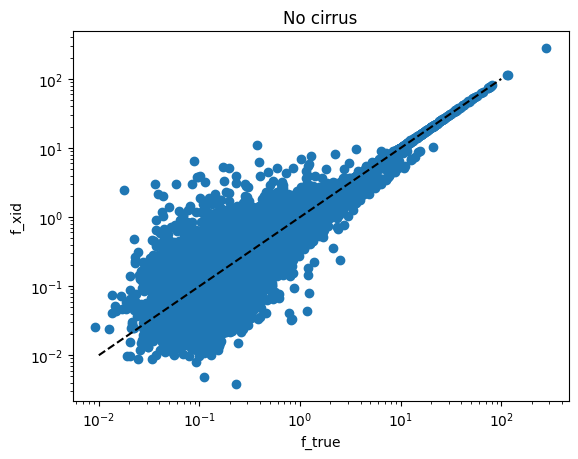

In [42]:
plt.plot([1e-2, 1e2], [1e-2, 1e2], c = "k", linestyle = "--")
plt.scatter(no_cirrus_true[no_cirrus_true>1e-9], no_cirrus_xid[no_cirrus_true>1e-9])
plt.yscale("log")
plt.xscale("log")
plt.title("No cirrus")
plt.xlabel("f_true")
plt.ylabel("f_xid")
plt.show()

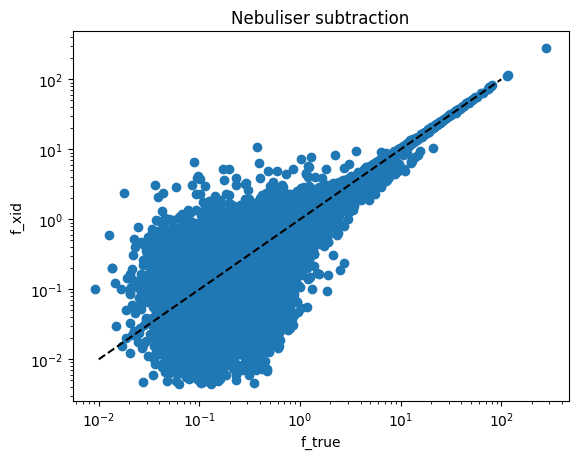

In [43]:
plt.plot([1e-2, 1e2], [1e-2, 1e2], c = "k", linestyle = "--")
plt.scatter(nebuliser_true[nebuliser_true>1e-9], nebuliser_xid[nebuliser_true>1e-9])
plt.yscale("log")
plt.xscale("log")
plt.title("Nebuliser subtraction")
plt.xlabel("f_true")
plt.ylabel("f_xid")
plt.show()

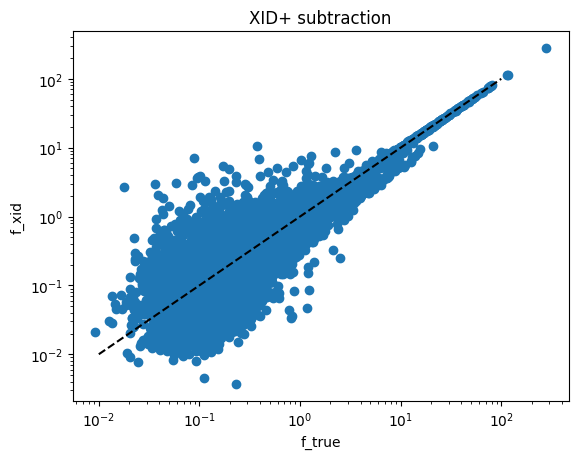

In [44]:
plt.plot([1e-2, 1e2], [1e-2, 1e2], c = "k", linestyle = "--")
plt.scatter(arr_new_true[arr_new_true>1e-9], arr_new_xid[arr_new_true>1e-9])
plt.yscale("log")
plt.xscale("log")
plt.title("XID+ subtraction")
plt.xlabel("f_true")
plt.ylabel("f_xid")
plt.show()

In [ ]:
# Limiting flux :)

In [45]:
import pandas as pd
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from tqdm import tqdm

def limiting_flux(f_xid, f_true, nbins=50):
    f_ratio = f_xid/f_true

    bmin = min(np.log10(f_true[f_true > 1e-9]))
    bmax = max(np.log10(f_true))

    bmin = -1
    bmax = 2

    bstep = (bmax - bmin)/nbins
    bins = np.arange(bmin,bmax+bstep,bstep)

    bin_width = (bins[1] - bins[0])
    bin_centers = bins[1:] - bin_width/2
    counts = np.zeros(len(bin_centers))
    mad = np.zeros(len(bin_centers))
    rms = np.zeros(len(bin_centers))

    for ii, i in enumerate(bins):
        if i == bins[-1]:
            pass
        else:
            ybin = f_ratio[(f_true >= np.power(10,bins[ii])) & (f_true < np.power(10,bins[ii+1]))]
            xbin = f_true[(f_true >= np.power(10,bins[ii])) & (f_true < np.power(10,bins[ii+1]))]
            counts[ii] = len(ybin)
            if len(ybin) > 0:
                ybin_mad = 1.4826 * np.percentile(np.abs(ybin - np.percentile(ybin,50)),50) # no need to do ybin-1, they cancel out

                mad[ii] = ybin_mad
                ybin_rms = np.sqrt(np.mean((ybin - 1)**2.0))
                rms[ii] = ybin_rms
    return mad, rms, counts, bin_centers

def get_lim(yarr,xarr,counts,lim):
    if max(yarr) < lim:
        return min(xarr)
    else:
        yarr = yarr[counts > 10] #mad
        xarr = xarr[counts > 10] #flux
        gt_lim_1st = yarr[yarr >= lim][-1]
        ind_gt_lim_1st = np.where(yarr == gt_lim_1st)[0][0]
        lim_line = yarr[ind_gt_lim_1st:ind_gt_lim_1st+2]
        lim_bins = xarr[ind_gt_lim_1st:ind_gt_lim_1st+2]
        interp = interp1d(lim_line,lim_bins)
        return interp(lim)

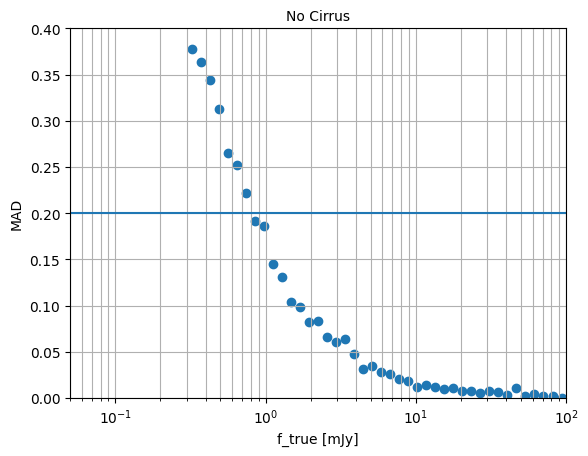

array(0.82136916)

In [50]:
xid, true = no_cirrus_xid, no_cirrus_true

mad, rms, counts, bin_centers = limiting_flux(xid, true)
plt.scatter(np.power(10,bin_centers), mad)
plt.xscale("log")
plt.xlim(5e-2,1e2)
plt.ylim(0,0.4)
plt.axhline(0.2)
plt.grid(which = "both")
plt.xlabel("f_true [mJy]")
plt.ylabel("MAD")
plt.title(f"No Cirrus", fontsize=10)
plt.show()

no_cirrus_lim = get_lim(mad,np.power(10,bin_centers),counts,0.2)
no_cirrus_lim

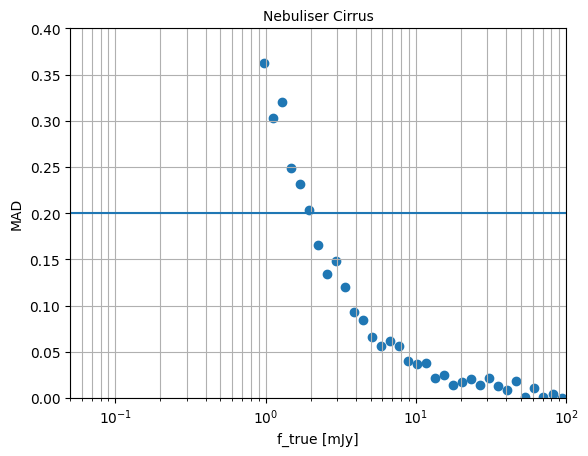

array(1.97279783)

In [51]:
xid, true = nebuliser_xid, nebuliser_true

mad, rms, counts, bin_centers = limiting_flux(xid, true)
plt.scatter(np.power(10,bin_centers), mad)
plt.xscale("log")
plt.xlim(5e-2,1e2)
plt.ylim(0,0.4)
plt.axhline(0.2)
plt.grid(which = "both")
plt.xlabel("f_true [mJy]")
plt.ylabel("MAD")
plt.title(f"Nebuliser Cirrus", fontsize=10)
plt.show()

nebuliser_lim = get_lim(mad,np.power(10,bin_centers),counts,0.2)
nebuliser_lim

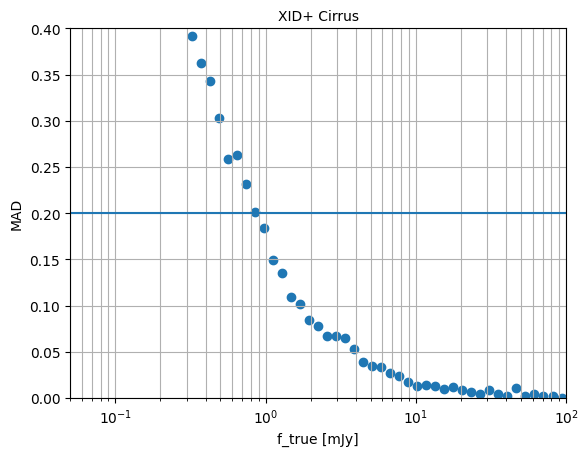

array(0.85801775)

In [52]:
xid, true = arr_new_xid, arr_new_true

mad, rms, counts, bin_centers = limiting_flux(xid, true)
plt.scatter(np.power(10,bin_centers), mad)
plt.xscale("log")
plt.xlim(5e-2,1e2)
plt.ylim(0,0.4)
plt.axhline(0.2)
plt.grid(which = "both")
plt.xlabel("f_true [mJy]")
plt.ylabel("MAD")
plt.title(f"XID+ Cirrus", fontsize=10)
plt.show()

new_lim = get_lim(mad,np.power(10,bin_centers),counts,0.2)
new_lim

In [53]:
new_lim/no_cirrus_lim

np.float64(1.0446189044409684)

In [54]:
nebuliser_lim/no_cirrus_lim

np.float64(2.401840646975444)

In [2]:
tile0 = 19923968

f = f"new_cirrus_modelling/xid_euclid_wide_v2.2_cirrus_2.5_testing_xid_modelling_larger_tile_PRIMA_2A_coadd_tile{tile0}_order11_large7.pkl"


    
with open(f, "rb") as f:
    data = pickle.load(f)

    prior = data["prior"]
    posterior = data["posterior"]
    kept_sources = data["kept_sources"]



In [4]:
type(prior.moc)

pymoc.moc.MOC

In [5]:
print(dir(prior.moc))

['__add__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__init__', '__init_subclass__', '__isub__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__weakref__', '_compare_operation', '_guess_file_type', '_normalized', '_order_num_cells', '_orders', '_type', '_validate_cell', '_validate_order', 'add', 'area', 'area_sq_deg', 'cells', 'clear', 'contains', 'copy', 'flattened', 'id', 'intersection', 'name', 'normalize', 'normalized', 'order', 'origin', 'read', 'remove', 'type', 'write']


In [6]:
help(prior.moc.contains)

Help on method contains in module pymoc.moc:

contains(order, cell, include_smaller=False) method of pymoc.moc.MOC instance
    Test whether the MOC contains the given cell.

    If the include_smaller argument is true then the MOC is considered
    to include a cell if it includes part of that cell (at a higher
    order).

    >>> m = MOC(1, (5,))
    >>> m.contains(0, 0)
    False
    >>> m.contains(0, 1, True)
    True
    >>> m.contains(0, 1, False)
    False
    >>> m.contains(1, 4)
    False
    >>> m.contains(1, 5)
    True
    >>> m.contains(2, 19)
    False
    >>> m.contains(2, 21)
    True

